<a href="https://colab.research.google.com/github/samirbagwan415-cmd/Machine_Learning_Lab/blob/main/Practical_No1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name:  BAGWAN SAMIR NASIR

Div: T.Y (CSE-1)

Practical Batch: A-1

Roll No: 14

Date: 09/09/2026

Practical NO: 01

Practical Name: Implement simple and multiple linear regression using Numpy and using Scikit-learn. Plot regression lines and residuals. Compute RMSE and R2 values.

1] import Libraries

In [27]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


2  Data Collection





In [28]:
import pandas as pd

# Create the dataset
data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Attendance": [60, 85, 70, 95, 65, 80, 90, 75, 88, 72],
    "Marks": [32, 42, 47, 58, 61, 67, 76, 79, 88, 91]
}

# Convert dict into DataFrame
df = pd.DataFrame(data)

print(df)


   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


3  EDA And Preprocessing


First Five Rows:
   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61

Last Five Rows:
   Study_Hours  Attendance  Marks
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91

Shape of Dataset:
(10, 3)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes

Statistical Analysis:
       Study_Hours  Attendance      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.

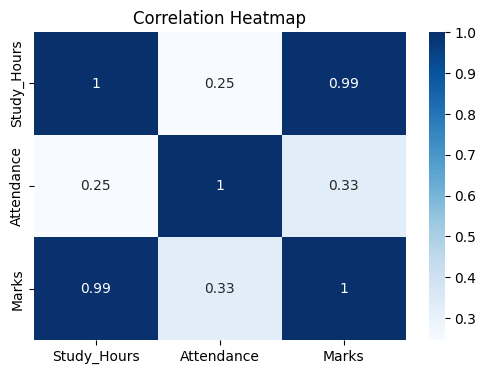

In [29]:
print("First Five Rows:")
print(df.head(5))

print("\nLast Five Rows:")
print(df.tail())

print("\nShape of Dataset:")
print(df.shape)

print("\nInformation:")
df.info()

print("\nStatistical Analysis:")
print(df.describe())

print("\nCheck for null values:")
print(df.isnull().sum())

# Remove rows containing null values
df = df.dropna()

print("\nDataset after removing null values:")
print(df)

# Check for duplicate values
print("\nDuplicate Values:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDataset after removing duplicates:")
print(df)
df_corr = df.corr()
df_corr

# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(df_corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()



A] Simple Linear Regression by Using Sckit-learn

In [21]:


X = df[['Study_Hours']]   # Independent Variable
y = df['Marks']           # Dependent Variable


4] Model Building

Intercept: 28.277227722772274
Slope: 6.475247524752477
RMSE: 0.949
R2 Score: 1.0


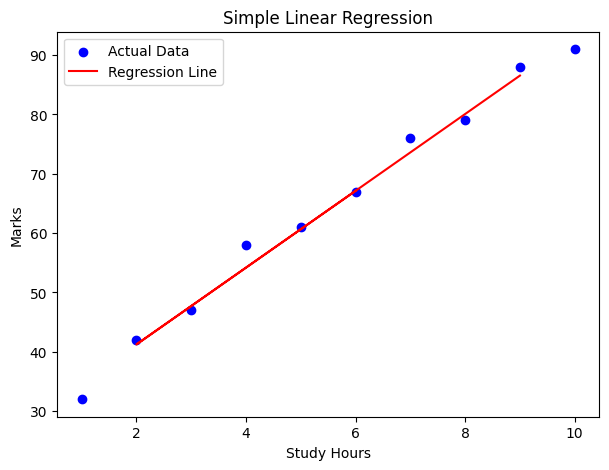

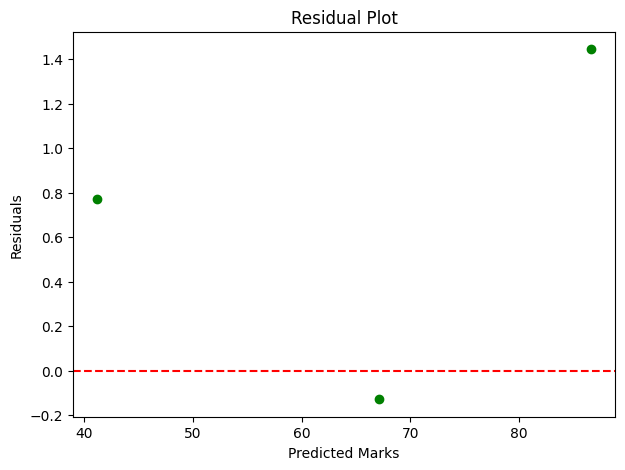

In [22]:
X = df[['Study_Hours']]
y = df['Marks']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])

import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', round(rmse, 3))
print('R2 Score:', round(r2, 2))

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


5] Model Evaluation

In [23]:
# Feature Selection
X = df[['Study_Hours']]   # Independent Variable
y = df['Marks']           # Dependent Variable


# Split dataset into training and testing set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# Import Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()


# Train the model
model.fit(X_train, y_train)


# Predict the values
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)


# Print Equation
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


# SLR Equation
print(
    f"SLR Equation: Marks = ({model.coef_[0]:.2f} * Study_Hours) + {model.intercept_:.2f}"
)


Predicted Values:
[86.55445545 41.22772277 67.12871287]
Intercept: 28.277227722772274
Slope: 6.475247524752477
SLR Equation: Marks = (6.48 * Study_Hours) + 28.28


B] Simple Linear Regression by using Numpy


In [24]:
X = df["Study_Hours"].values
y = df["Marks"].values

X_mean = np.mean(X)
y_mean = np.mean(y)

print("X Mean =", X_mean)
print("Y Mean =", y_mean)

m = np.sum((X - X_mean) * (y - y_mean)) / np.sum((X - X_mean) ** 2)

b = y_mean - m * X_mean

print("Slope =", m)
print("Intercept =", b)

y_pred_numpy = m * X + b

print("Predicted Values:")
print(y_pred_numpy)


X Mean = 5.5
Y Mean = 64.1
Slope = 6.503030303030303
Intercept = 28.33333333333333
Predicted Values:
[34.83636364 41.33939394 47.84242424 54.34545455 60.84848485 67.35151515
 73.85454545 80.35757576 86.86060606 93.36363636]


c]Multiple Linear Regression

[88.08653885 43.59718321 67.84336712]
Intercept: 16.14458419831481
       Feature  Coefficient
0  Study_Hours     6.280539
1   Attendance     0.175194
Metrics Values of MLR:
MAE: 0.84
RMSE: 1.04
R2 Score: 1.0


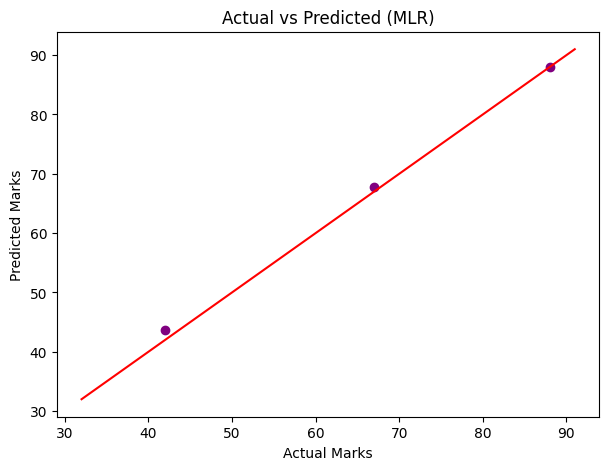

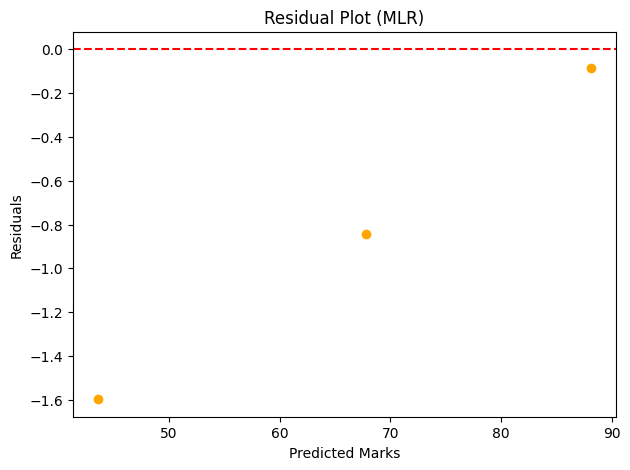

In [25]:
# Feature Selection
X = df[['Study_Hours', 'Attendance']]
y = df['Marks']

# Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model Building
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
print(y_pred)

# Model Parameters
print('Intercept:', model.intercept_)

coeff = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff)

# Model Evaluation

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('Metrics Values of MLR:')
print('MAE:', round(mae, 2))
print('RMSE:', round(rmse, 2))
print('R2 Score:', round(r2, 2))

# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, color='purple')

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color='red'
)

plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted (MLR)')
plt.show()

# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals, color='orange')
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot (MLR)')
plt.show()
